# Milestone 2: Advanced Data Analysis and Feature Engineering

In this notebook, we will perform time series analysis and engineer features for machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import sys
import os
sys.path.append(os.path.abspath('../'))

sns.set_theme(style="whitegrid")

## 1. Load Data
We load the aggregated daily sales data from Milestone 1.

In [2]:
df = pd.read_csv('../data/processed/time_series_sales.csv', parse_dates=['order_purchase_timestamp'], index_col='order_purchase_timestamp')
df = df.asfreq('D') # Ensure daily frequency
df['total_sales'] = df['total_sales'].fillna(0)
df.head()

,total_sales,total_items,total_orders
order_purchase_timestamp,,,
2016-09-04,72.89,2,1
2016-09-05,0.00,0,0
2016-09-06,0.00,0,0
2016-09-07,0.00,0,0
2016-09-08,0.00,0,0


## 2. Time Series Decomposition
Decompose the series into Trend, Seasonality, and Residuals.

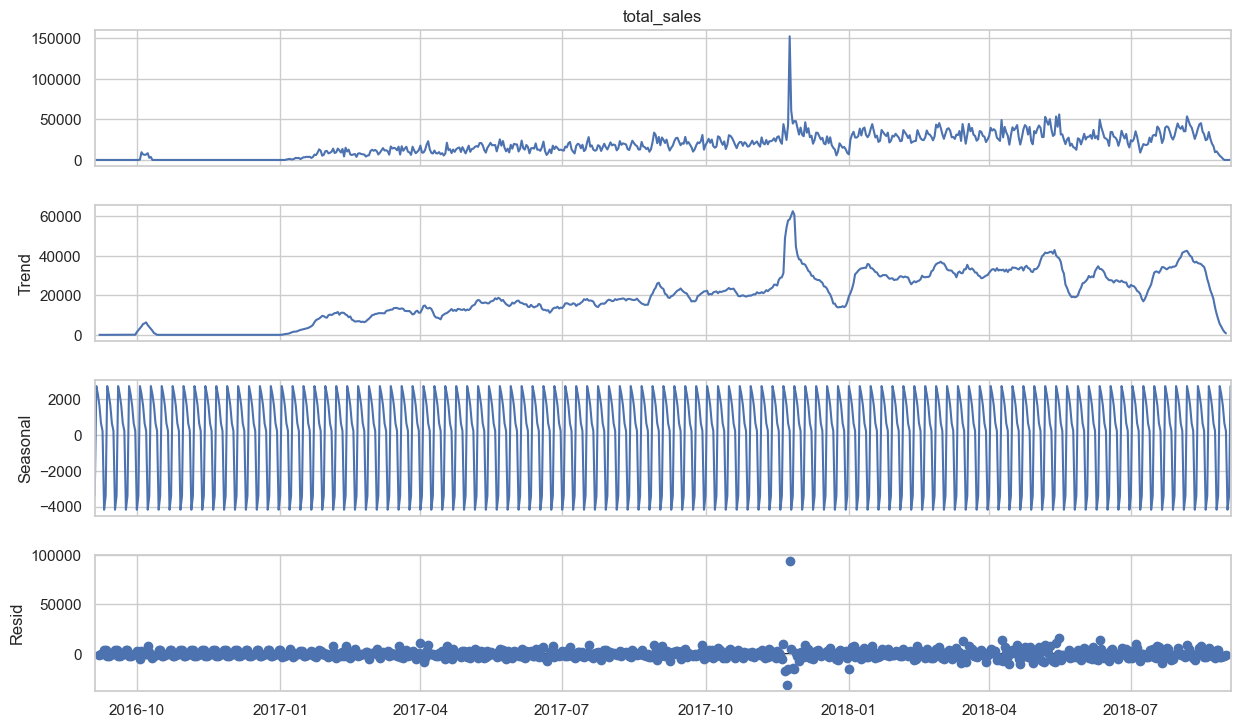

In [3]:
decomposition = seasonal_decompose(df['total_sales'], model='additive')
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()

## 3. Stationarity Testing (ADF Test)
Check if the time series is stationary.

In [4]:
def adf_test(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis, reject the null hypothesis. Data is stationary.")
    else:
        print("Weak evidence against null hypothesis, time series is non-stationary.")

adf_test(df['total_sales'])

ADF Statistic: -2.19084647745398
p-value: 0.20958441566541758
Weak evidence against null hypothesis, time series is non-stationary.


## 4. Autocorrelation (ACF & PACF)
Analyze lags to determine useful features.

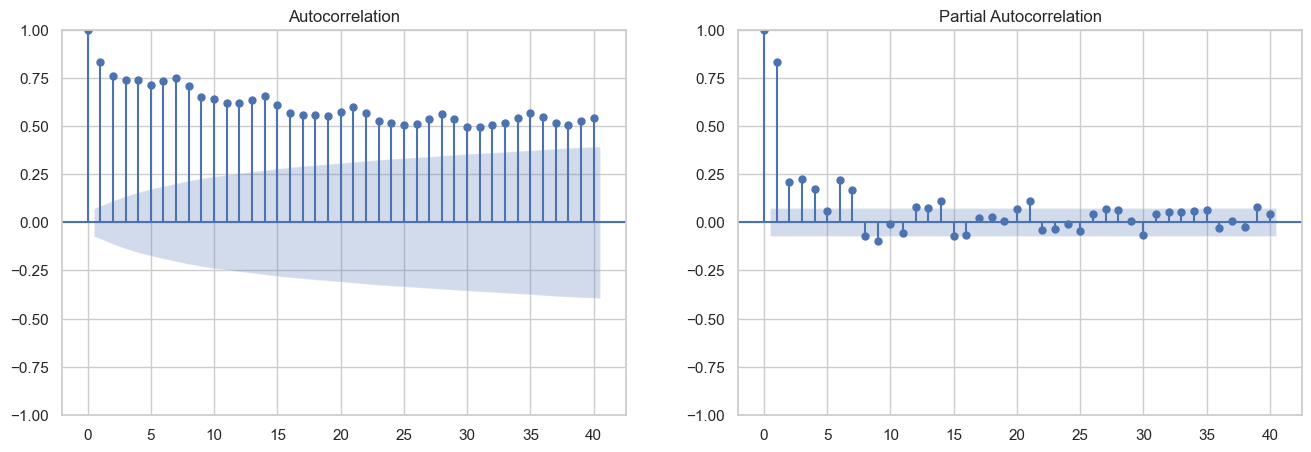

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['total_sales'].dropna(), lags=40, ax=ax[0])
plot_pacf(df['total_sales'].dropna(), lags=40, ax=ax[1])
plt.show()

## 5. Feature Engineering
We use the script to generate features and save them for the next milestone (3 milestone).

In [6]:
from src.feature_engineering import feature_engineering_pipeline

input_path = '../data/processed/time_series_sales.csv'
output_path = '../data/processed/features_sales.csv'
feature_engineering_pipeline(input_path, output_path)

features_df = pd.read_csv(output_path, index_col='order_purchase_timestamp', parse_dates=True)
features_df.head()

Creating time features...
Adding holiday flags for BR...
Creating lag features...
Creating rolling features...
Engineered features saved to ../data/processed/features_sales.csv


,total_sales,total_items,total_orders,day_of_week,month,quarter,is_weekend,is_holiday,total_sales_lag_1,total_sales_lag_7,total_sales_lag_14,total_sales_lag_30,total_sales_rolling_avg_7,total_sales_rolling_std_7,total_sales_rolling_avg_30,total_sales_rolling_std_30
order_purchase_timestamp,,,,,,,,,,,,,,,,
2016-10-04,9571.16,67,58,1,10,4,0,0,441.98,0.0,0.0,72.89,1430.448571,3593.493385,338.270333,1745.811366
2016-10-05,6856.56,52,39,2,10,4,0,0,9571.16,0.0,0.0,0.00,2409.957143,4044.741671,566.822333,2110.682642
2016-10-06,6295.72,55,46,3,10,4,0,0,6856.56,0.0,0.0,0.00,3309.345714,4118.830174,776.679667,2351.611576
2016-10-07,6728.25,50,43,4,10,4,0,0,6295.72,0.0,0.0,0.00,4270.524286,4001.221892,1000.954667,2584.310840
2016-10-08,8306.86,43,38,5,10,4,1,0,6728.25,0.0,0.0,0.00,5457.218571,3747.345389,1277.850000,2899.199799
